# Demonstrate Heteroscedastic GP (revisited)

Show the fitting and predictions using heteroscedastic GP. Model is trained to predict the cubic cosine data with linear heteroscedastic noise.

**Feb 18th, 2026 update**: Use implementation of variational heteroskedastic GP (VHGP) as introduced by Lázaro-Gredilla & Titsias 2011 (https://dl.acm.org/doi/10.5555/3104482.3104588)

In [2]:
import logging

from dotenv import load_dotenv

import matplotlib.pyplot as plt

import numpy as np

from scipy import stats

import seaborn as sns

import torch


# Force autoreload
%load_ext autoreload
%autoreload 2

# Logger
logger = logging.getLogger()
logging.basicConfig(
    format='%(asctime)s %(levelname)s: %(message)s',
    level=logging.INFO,
    datefmt='%I:%M:%S'
)

# Load dotenv
_ = load_dotenv()

## Generate and plot training data

In [3]:
from gp_sand.generate import PowerCosineHeteroscedastic

gene = PowerCosineHeteroscedastic(noise_intercept=.01)

train_x, train_y = gene.training_data(1000)
obs_noise = train_y - gene.true_signal(train_x)

x_test = np.linspace(-15, 15)
y_true = gene.true_signal(x_test)
sigma = gene.noise(x_test)**.5

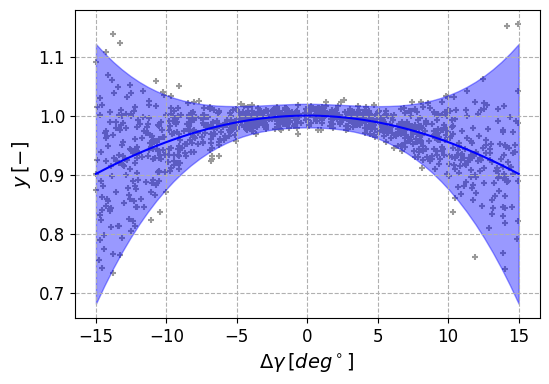

In [4]:
_, ax = plt.subplots(figsize=(6, 4))
ax.grid(ls='--')


ax.scatter(
    train_x,
    train_y,
    marker='+',
    s=15,
    c='0.6',
    zorder=1,
    label='observations'
)
ax.plot(x_test, y_true, c='b')
ax.fill_between(
    x_test,
    y_true - 2 * sigma,
    y_true + 2 * sigma,
    alpha=.4,
    color='b'
)

ax.set(
    xlabel=r'$\Delta\gamma\, [deg^\circ]$',
    ylabel=r'$y\, [-]$'
);

## Fit the model

### Standard homoskedastic model

In [5]:
from gp_sand.models import BaseExactGP

baseline_gp = BaseExactGP(train_x, train_y)

In [6]:
baseline_gp.fit(train_x, train_y);

11:01:05 INFO: Iter 1 of 250: Noise:  0.644 - Loss:  0.821
11:01:05 INFO: Iter 25 of 250: Noise:  0.075 - Loss: -0.282
11:01:06 INFO: Iter 50 of 250: Noise:  0.006 - Loss: -1.424
11:01:07 INFO: Iter 75 of 250: Noise:  0.001 - Loss: -1.693
11:01:08 INFO: Iter 100 of 250: Noise:  0.002 - Loss: -1.712
11:01:08 INFO: Iter 125 of 250: Noise:  0.002 - Loss: -1.710
11:01:09 INFO: Iter 150 of 250: Noise:  0.002 - Loss: -1.710
11:01:10 INFO: Iter 175 of 250: Noise:  0.002 - Loss: -1.710
11:01:11 INFO: Iter 200 of 250: Noise:  0.002 - Loss: -1.712
11:01:11 INFO: Iter 225 of 250: Noise:  0.002 - Loss: -1.703
11:01:12 INFO: Iter 250 of 250: Noise:  0.002 - Loss: -1.713
/home/songz/Learning/pygp-sandox/.venv/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
11:01:12 INFO: Prediction scores:
+--------+--------+-----------+-------+-------+--------+-------+
| target |  bias  |

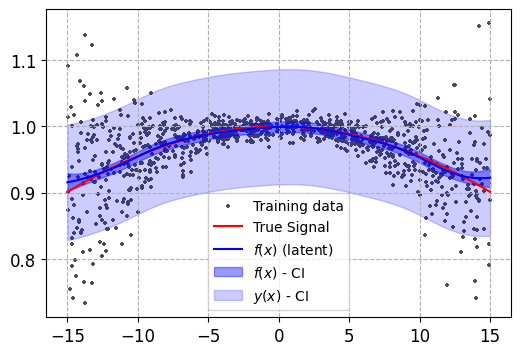

In [7]:
test_x = torch.linspace(-15, 15, 151)
test_y = gene.true_signal(test_x)

f_pred, lower_f, upper_f = baseline_gp.predict_latent(test_x)
_, lower, upper = baseline_gp.predict(test_x) 


_, ax = plt.subplots(figsize=(6, 4))
ax.grid(ls='--')


ax.scatter(train_x, train_y, s=5, marker='+', c='.3', zorder=1, label='Training data')
ax.plot(test_x, test_y, c='r', label='True Signal')
ax.plot(test_x, f_pred.mean, c='b', label='$f(x)$ (latent)')

ax.fill_between(
    test_x.numpy(),
    lower_f.numpy(),
    upper_f.numpy(),
    color='b',
    alpha=.4,
    label='$f(x)$ - CI'
)
ax.fill_between(
    test_x.numpy(),
    lower.numpy(),
    upper.numpy(),
    color='b',
    alpha=.2,
    label='$y(x)$ - CI'
)
ax.legend()

### Heteroskedastic model

In [8]:
from gpytorch.kernels import ConstantKernel, MaternKernel, RBFKernel, ScaleKernel

from gp_sand.models import VariationalHeteroscedasticGP


mean_y = train_y.mean()
train_y0 = train_y - mean_y

model = VariationalHeteroscedasticGP(
    train_x,
    train_y0,
    covar_latent=baseline_gp.covar_module,
    covar_noise=ScaleKernel(RBFKernel()) + ConstantKernel(),
    jitter=1e-3,
)

In [9]:
# model.jitter = 1e-4
model.fit(train_x, train_y0);

11:01:13 INFO: Pre-training (homoscedastic) latent and noise models.
11:01:13 INFO: Pre-train latent GP (homoscedastic).
11:01:13 INFO: Iter 1 of 150: Noise:  0.644 - Loss:  0.738
11:01:13 INFO: Iter 25 of 150: Noise:  0.075 - Loss: -0.310
11:01:14 INFO: Iter 50 of 150: Noise:  0.006 - Loss: -1.430
11:01:15 INFO: Iter 75 of 150: Noise:  0.001 - Loss: -1.693
11:01:15 INFO: Iter 100 of 150: Noise:  0.002 - Loss: -1.710
11:01:16 INFO: Iter 125 of 150: Noise:  0.002 - Loss: -1.712
11:01:17 INFO: Iter 150 of 150: Noise:  0.002 - Loss: -1.709
/home/songz/Learning/pygp-sandox/.venv/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
11:01:17 INFO: Prediction scores:
+--------+-------+-----------+---------------+-------+--------+-------+
| target |  bias | bias_perc |      cov      |  mae  | nrmse  |  rmse |
+--------+-------+-----------+---------------+-------+--------+

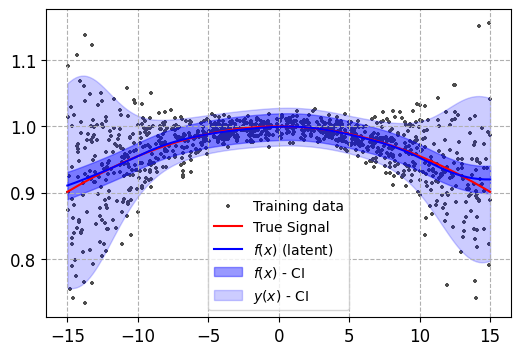

In [10]:
test_x = torch.linspace(-15, 15, 151)
test_y = gene.true_signal(test_x)


f_pred, lower_f, upper_f = model.predict_latent(test_x)
_, lower, upper = model.predict(test_x) 


_, ax = plt.subplots(figsize=(6, 4))
ax.grid(ls='--')


ax.scatter(train_x, train_y, s=5, marker='+', c='.3', zorder=1, label='Training data')
ax.plot(test_x, test_y, c='r', label='True Signal')
ax.plot(test_x, mean_y + f_pred.mean, c='b', label='$f(x)$ (latent)')

ax.fill_between(
    test_x,
    mean_y + lower_f,
    mean_y + upper_f,
    color='b',
    alpha=.4,
    label='$f(x)$ - CI'
)
ax.fill_between(
    test_x.numpy(),
    mean_y + lower,
    mean_y + upper,
    color='b',
    alpha=.2,
    label='$y(x)$ - CI'
)
ax.legend()

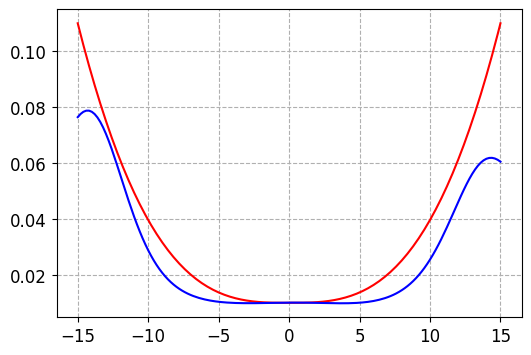

In [11]:
test_var = gene.noise(test_x)
with torch.no_grad():
    pred_var = model.predictive_noise(test_x)._diag

_, ax = plt.subplots(figsize=(6, 4))
ax.grid(ls='--')


ax.plot(test_x, test_var**.5, c='r', label='True Variance')

ax.plot(
    test_x,
    pred_var**.5,
    c='b'
)